In [1]:
import xmitgcm as xm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl
import matplotlib.colors as mcolors
import xhistogram.xarray as xhist
import jmkfigure

<IPython.core.display.Javascript object>

<xarray.Dataset> Size: 51MB
Dimensions:              (XC: 960, YC: 1, XG: 960, YG: 1, Z: 200, Zp1: 201,
                          Zu: 200, Zl: 200, layer_1TH_bounds: 101,
                          layer_1TH_center: 100, layer_1TH_interface: 99,
                          time: 30)
Coordinates: (12/46)
  * XC                   (XC) float64 8kB 2.957e+03 8.554e+03 ... 1.466e+05
  * YC                   (YC) float64 8B 50.0
  * XG                   (XG) float64 8kB 0.0 5.914e+03 ... 1.465e+05 1.466e+05
  * YG                   (YG) float64 8B 0.0
  * Z                    (Z) float64 2kB -5.0 -15.0 ... -1.985e+03 -1.995e+03
  * Zp1                  (Zp1) float64 2kB 0.0 -10.0 -20.0 ... -1.99e+03 -2e+03
    ...                   ...
    dyF                  (YC, XC) float64 8kB dask.array<chunksize=(1, 960), meta=np.ndarray>
  * layer_1TH_bounds     (layer_1TH_bounds) float64 808B 23.92 23.96 ... 27.98
  * layer_1TH_center     (layer_1TH_center) float64 800B 23.94 23.98 ... 27.96
  * layer_1TH_interface  (layer_1TH_interface) float64 792B 23.96 24.0 ... 27.94
    iter                 (time) int64 240B dask.array<chunksize=(1,), meta=np.ndarray>
  * time                 (time) timedelta64[ns] 240B 0 days 12:24:00 ... 15 d...
Data variables:
    LaUH1TH              (time, layer_1TH_center, YC, XG) float64 23MB dask.array<chunksize=(1, 100, 1, 960), meta=np.ndarray>
    LaHw1TH              (time, layer_1TH_center, YC, XG) float64 23MB dask.array<chunksize=(1, 100, 1, 960), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../results/Sl...

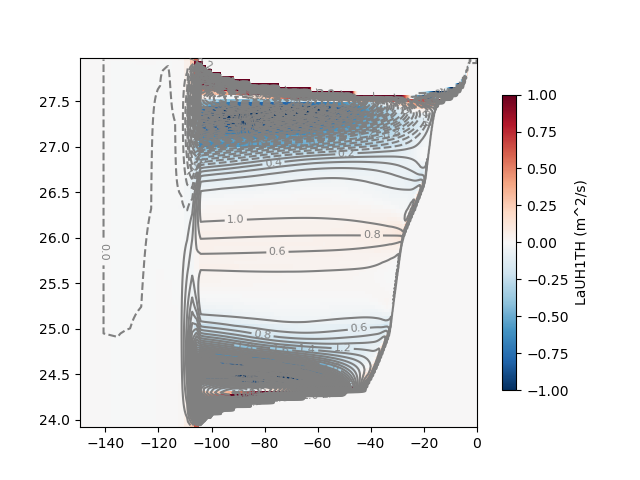

In [2]:
todos = ['WavySlope001constN400u060', 'WavySlope001constN200u060', 'Slope2D007', 'Slope2D008']
td = todos[-1]
with xm.open_mdsdataset(f'../results/{td}/input/', iters='all', endian='<', prefix='layDiag', clear_cache=True) as ds0:
    display(ds0)
    ds0 = ds0.isel(YC=0, YG=0, time=slice(-5, None))
    ds0['XG'] = (ds0.XG - ds0.XC[-1]) / 1e3
    ds0['XC'] = (ds0.XC - ds0.XC[-1]) / 1e3

    fig, ax = plt.subplots()
    pc = ax.pcolormesh(ds0.XG, ds0.layer_1TH_center, ds0.LaUH1TH.mean(dim='time'), cmap='RdBu_r', vmin=-1, vmax=1)
    cum = ds0.LaUH1TH.cumsum(dim='layer_1TH_center').mean(dim='time')
    cs = ax.contour(ds0.XG, ds0.layer_1TH_center, cum, levels=np.arange(-15, 15, 0.2), colors='0.5')
    ax.clabel(cs, inline=True, fontsize=8)
    fig.colorbar(pc, ax=ax, label='LaUH1TH (m^2/s)', orientation='vertical', shrink=0.8)
    ax.set_facecolor('0.6')


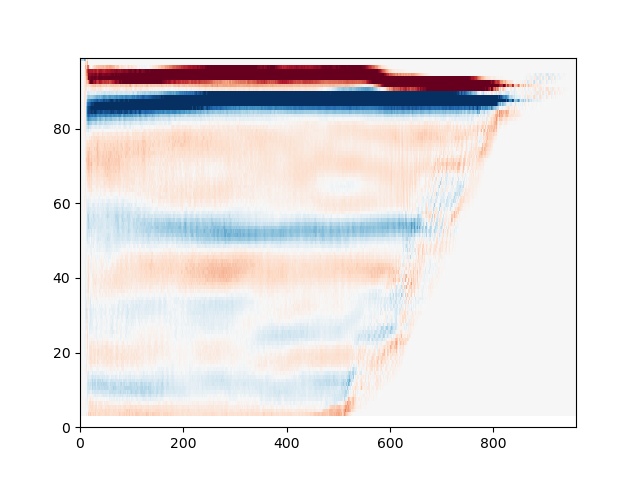

In [ ]:
fig, ax = plt.subplots()
ax.pcolormesh(hist.T.rolling(XG=1, thetaG_bin=4).mean()/24, cmap='RdBu_r', vmin=-5, vmax=5)

In [10]:
display(hist)

<xarray.DataArray 'histogram_thetaG' (XG: 960, thetaG_bin: 199)> Size: 2MB
dask.array<sum-aggregate, shape=(960, 199), dtype=float64, chunksize=(960, 199), chunktype=numpy.ndarray>
Coordinates:
  * XG          (XG) float64 8kB 0.0 5.914e+03 1.119e+04 ... 1.465e+05 1.466e+05
  * thetaG_bin  (thetaG_bin) float64 2kB 23.93 23.95 23.97 ... 27.93 27.95 27.97

In [38]:
ds0

<xarray.Dataset> Size: 21MB
Dimensions:              (XC: 960, XG: 960, Z: 200, Zp1: 201, Zu: 200, Zl: 200,
                          layer_1TH_bounds: 101, layer_1TH_center: 100,
                          layer_1TH_interface: 99, time: 10)
Coordinates: (12/46)
  * XC                   (XC) float64 8kB 2.957e+03 8.554e+03 ... 1.466e+05
    YC                   float64 8B 50.0
  * XG                   (XG) float64 8kB 0.0 5.914e+03 ... 1.465e+05 1.466e+05
    YG                   float64 8B 0.0
  * Z                    (Z) float64 2kB -5.0 -15.0 ... -1.985e+03 -1.995e+03
  * Zp1                  (Zp1) float64 2kB 0.0 -10.0 -20.0 ... -1.99e+03 -2e+03
    ...                   ...
    dyF                  (XC) float64 8kB dask.array<chunksize=(960,), meta=np.ndarray>
  * layer_1TH_bounds     (layer_1TH_bounds) float64 808B 23.92 23.96 ... 27.98
  * layer_1TH_center     (layer_1TH_center) float64 800B 23.94 23.98 ... 27.96
  * layer_1TH_interface  (layer_1TH_interface) float64 792B 23.96 24.0 ... 27.94
    iter                 (time) int64 80B dask.array<chunksize=(1,), meta=np.ndarray>
  * time                 (time) timedelta64[ns] 80B 5 days 16:24:00 ... 10 da...
Data variables:
    LaUH1TH              (time, layer_1TH_center, XG) float64 8MB dask.array<chunksize=(1, 100, 960), meta=np.ndarray>
    LaHw1TH              (time, layer_1TH_center, XG) float64 8MB dask.array<chunksize=(1, 100, 960), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../results/Wa...